# Maize Leaf Disease Classification: Traditional ML vs Deep Learning

**Author:** Adossi Fred William

**Course:** Introduction to Machine Learning - Summative Project

**GitHub:** https://github.com/Adossi-design/maize-leaf-disease-classification

## 1. Introduction

Maize is a key crop in East Africa and Rwanda, and leaf diseases can wipe out a lot of a farmer's harvest if they are not caught early. This project builds a model that can look at a photo of a maize leaf and say which disease it has, or whether the leaf is healthy.

I tested four classes, Blight, Common Rust, Gray Leaf Spot, and Healthy, and I compared two types of models: traditional machine learning (Scikit-learn) using features I built by hand, and deep learning (TensorFlow) where the network finds its own features straight from the pixels. What I really wanted to find out was not just which approach gets the higher score, but where each one breaks down and why some leaves end up being so much harder to classify than others.

The dataset is far from balanced, since Gray Leaf Spot only has 574 images while Common Rust has more than twice that at 1,306, and instead of trying to hide this gap I leaned into it and ran experiments specifically to measure how much difference the imbalance actually makes.

### How this notebook is organised
1. Introduction
2. Setup and reproducibility
3. Load data and explore
4. Train / validation / test split
5. Preprocessing
6. Traditional ML models (Experiments 1 to 3)
7. Deep learning models (Experiments 4 to 9)
8. Results table
9. Evaluation and error analysis
10. Discussion and conclusion

## 2. Setup and Reproducibility

I import all the libraries I need and fix every random seed right at the top, so that the results stay the same every single time I run the notebook, because if I skipped this step the splits and the model weights would shift on each run and I would no longer be able to compare experiments fairly.

I also set up two shared containers here: `results` collects the metrics from every experiment and becomes the table you see in Section 8, while `model_store` keeps each model's predictions so that the plots in Section 9 can reuse them, and both the classical and the deep-learning sections write into these same two objects.

In [1]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, auc, precision_recall_curve)

# ---- Reproducibility ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Seed:", SEED)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed: 42


In [2]:
# Output folders for figures and saved models.
FIG_DIR = "figures"
MODEL_DIR = "models"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Shared containers, defined once so every section can use them.
results = []
model_store = {}

def log_result(exp_id, approach, model_name, settings, acc, macro_f1, notes):
    results.append({
        "Exp": exp_id, "Approach": approach, "Model": model_name,
        "Key settings": settings, "Accuracy": round(acc, 4),
        "Macro-F1": round(macro_f1, 4), "Notes / insight": notes,
    })
    print(f"[{exp_id}] {model_name}: acc={acc:.4f}, macro-F1={macro_f1:.4f}")

## 3. Load Data and Explore

I ran this whole project on Google Colab with the dataset stored as a single zip file in my Google Drive, because keeping it zipped in Drive and then unzipping it onto Colab's local disk at the start of each session is far faster than reading thousands of small image files straight from Drive every time. The only thing to keep in mind is that Colab wipes its local storage once the session ends, but that is completely fine here because the original zip always stays safe back in Drive.


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import zipfile

# Where the zip lives in your Drive, and where to unzip it on Colab's local disk.
ZIP_PATH = "/content/drive/MyDrive/dataset.zip"
EXTRACT_TO = "/content/maize_data"

if not os.path.isdir(EXTRACT_TO):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_TO)
    print("Extracted to", EXTRACT_TO)
else:
    print("Already extracted.")

# Auto-detect the folder that actually contains the four class subfolders.
EXPECTED = {"Blight", "Common_Rust", "Gray_Leaf_Spot", "Healthy"}
DATA_DIR = None
for root, dirs, files in os.walk(EXTRACT_TO):
    if EXPECTED.issubset(set(dirs)):
        DATA_DIR = root
        break

assert DATA_DIR is not None, "Could not find the four class folders after unzipping."
CLASSES = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
NUM_CLASSES = len(CLASSES)
print("DATA_DIR =", DATA_DIR)
print("Classes:", CLASSES)

Mounted at /content/drive
Extracted to /content/maize_data
DATA_DIR = /content/maize_data/data
Classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


### 3.1 Build a table of image paths and labels

Instead of working with the folders directly, I load all of the image paths and their labels into one single dataframe, which makes the stratified split simple and, more importantly, makes sure that both the ML and the DL models train and test on the exact same images, because if the two approaches were trained and tested on different splits then any comparison between them would not really be fair.

In [4]:
import glob
IMG_EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

rows = []
for cls in CLASSES:
    for path in glob.glob(os.path.join(DATA_DIR, cls, "*")):
        if path.endswith(IMG_EXTS):
            rows.append({"filepath": path, "label": cls})

df = pd.DataFrame(rows)
print("Total images:", len(df))
print(df["label"].value_counts())
df.head()

Total images: 4188
label
Common_Rust       1306
Healthy           1162
Blight            1146
Gray_Leaf_Spot     574
Name: count, dtype: int64


,filepath,label
0,/content/maize_data/data/Blight/Corn_Blight (7...,Blight
1,/content/maize_data/data/Blight/Corn_Blight (5...,Blight
2,/content/maize_data/data/Blight/Corn_Blight (4...,Blight
3,/content/maize_data/data/Blight/Corn_Blight (3...,Blight
4,/content/maize_data/data/Blight/Corn_Blight (2...,Blight


### 3.2 Show a sample from each class

Looking at a single image from each class gives a quick feel for what the models are actually working with: Common Rust stands out immediately because of its clear orange spots, whereas Gray Leaf Spot is far more subtle and tends to blend into the rest of the leaf. Even from just these few example images you can already start to guess which classes are going to be easy and which ones are going to give every model trouble later on.

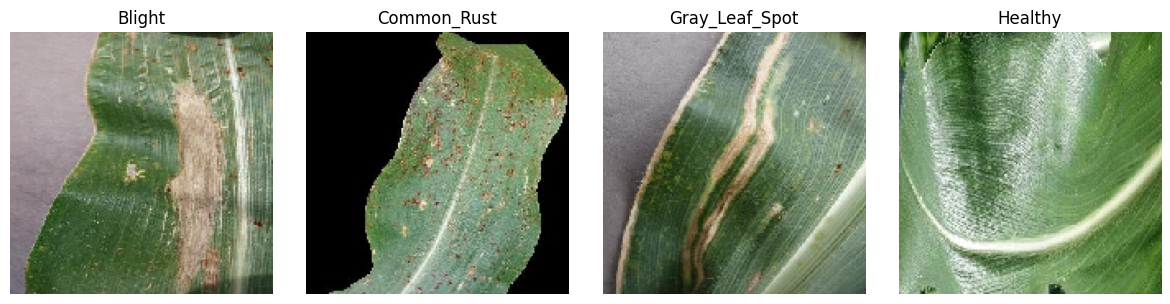

In [5]:
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(12, 3))
for i, cls in enumerate(CLASSES):
    sample = df[df.label == cls].iloc[0].filepath
    plt.subplot(1, NUM_CLASSES, i + 1)
    plt.imshow(load_img(sample, target_size=(160, 160)))
    plt.title(cls); plt.axis("off")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/class_samples.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.3 Class distribution

Here I count how many images sit in each class, which confirms the imbalance I mentioned earlier, and because of that imbalance I report macro-F1 alongside plain accuracy, since accuracy on its own can look perfectly healthy even when the smallest class is being predicted badly almost every single time.

/tmp/ipykernel_896/1445696285.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


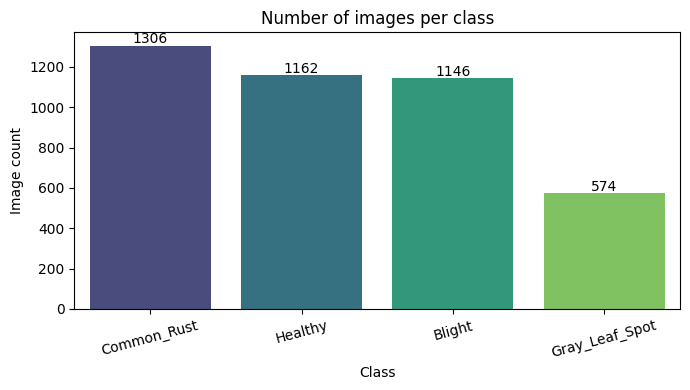

Imbalance ratio (largest:smallest) = 2.28 : 1


In [6]:
counts = df["label"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Number of images per class")
plt.ylabel("Image count"); plt.xlabel("Class"); plt.xticks(rotation=15)
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Imbalance ratio (largest:smallest) = {counts.max()/counts.min():.2f} : 1")

## 4. Train / Validation / Test Split

I split the data into 70% train, 15% validation, and 15% test using stratified sampling, so that each class keeps its natural proportion in every split, and this matters most for Gray Leaf Spot because a plain random split could easily leave too few of its images in the test set to measure anything reliably.

I do this in two steps with a fixed seed, first pulling out 15% as the test set and then splitting whatever is left into training and validation, and from that point on the test set is never touched again until the very end, so that both the ML and the deep-learning models are always measured on exactly the same held-out images.

In [7]:
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df["label"], random_state=SEED)

val_fraction = 0.15 / 0.85  # makes val ~15% of the whole set
train_df, val_df = train_test_split(
    train_val_df, test_size=val_fraction, stratify=train_val_df["label"], random_state=SEED)

train_df = train_df.assign(split="train")
val_df   = val_df.assign(split="val")
test_df  = test_df.assign(split="test")

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_df.to_csv("split.csv", index=False)

print(split_df["split"].value_counts())
print()
print(pd.crosstab(split_df["label"], split_df["split"]))

split
train    2930
val       629
test      629
Name: count, dtype: int64

split           test  train  val
label                           
Blight           172    802  172
Common_Rust      196    914  196
Gray_Leaf_Spot    86    402   86
Healthy          175    812  175


## 5. Preprocessing: Two Paths

The traditional ML models and the deep learning models need the data in very different forms, so I prepare it in two separate ways starting from the same underlying split.

For the **traditional ML models** I turn each image into a feature vector by hand, using an HSV colour histogram plus HOG texture features, because these classical models cannot do anything useful with the raw pixels on their own.

For the **deep learning models** I build a `tf.data` pipeline that reads the images, resizes them, scales the pixels to [0, 1], batches them, and prefetches, and the CNN then learns its own features from those pixels so that no hand-engineering is needed on this path at all.

This difference, between the features I design myself and the features the network learns for itself, is really the main thing being compared across the two approaches in this whole project.

### 5.1 Handcrafted features for the ML models

For each image I extract two types of features, an HSV colour histogram (8 bins per channel, 24 numbers in total) together with HOG features for edges and texture, and I chose HSV because disease lesions change a leaf's colour in ways that show up far more clearly in HSV than in plain RGB, while the HOG part captures the shapes and patterns of those same lesions. The images are loaded at 64x64 because these particular features do not need a high resolution and the smaller size keeps the extraction fast, so running this over a few thousand images only takes a couple of minutes, which is completely normal.

In [8]:
from skimage.feature import hog
from skimage.color import rgb2gray, rgb2hsv
from tensorflow.keras.preprocessing.image import img_to_array, load_img

FEAT_SIZE = (64, 64)

def extract_features(path):
    img = img_to_array(load_img(path, target_size=FEAT_SIZE)) / 255.0
    hsv = rgb2hsv(img)
    hist = []
    for ch in range(3):
        h, _ = np.histogram(hsv[:, :, ch], bins=8, range=(0, 1))
        hist.extend(h)
    hist = np.array(hist, dtype="float32")
    hist = hist / (hist.sum() + 1e-7)
    gray = rgb2gray(img)
    hog_feat = hog(gray, orientations=8, pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2), feature_vector=True)
    return np.concatenate([hist, hog_feat]).astype("float32")

def build_xy(frame):
    X = np.stack([extract_features(p) for p in frame.filepath.values])
    return X, frame.label.values

print("Extracting features... (a few minutes)")
t0 = time.time()
X_train, y_train = build_xy(train_df)
X_val,   y_val   = build_xy(val_df)
X_test,  y_test  = build_xy(test_df)
print(f"Done in {time.time()-t0:.0f}s. Feature vector length = {X_train.shape[1]}")

le = LabelEncoder().fit(CLASSES)
y_train_i, y_val_i, y_test_i = le.transform(y_train), le.transform(y_val), le.transform(y_test)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print("Feature matrices ready and standardised.")

Extracting features... (a few minutes)
Done in 20s. Feature vector length = 312
Feature matrices ready and standardised.


### 5.2 `tf.data` pipeline for the deep learning models

For the deep models I build the input pipeline with the `tf.data` API, where each image is read from disk, decoded, resized to 128x128, and scaled into the [0, 1] range. On top of that I add `cache()` so every image is only read once per run, `shuffle()` during training, `batch()`, and `prefetch(AUTOTUNE)` so that the GPU is never left sitting idle waiting for the next batch of data to arrive. I deliberately kept the images at 128x128 so that I could run all of these experiments on Colab's free GPU without running out of memory, and the class weights used later in the imbalance experiments are also computed right here in the same place.

In [9]:
IMG_SIZE = (128, 128)
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(frame, shuffle=False):
    paths = frame.filepath.values
    labels = le.transform(frame.label.values)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(load, num_parallel_calls=AUTOTUNE).cache()
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, shuffle=True)
val_ds   = make_ds(val_df)
test_ds  = make_ds(test_df)

cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES),
                          y=le.transform(train_df.label.values))
class_weights = {i: w for i, w in enumerate(cw)}
print("Class weights:", {CLASSES[i]: round(w, 2) for i, w in class_weights.items()})

Class weights: {'Blight': np.float64(0.91), 'Common_Rust': np.float64(0.8), 'Gray_Leaf_Spot': np.float64(1.82), 'Healthy': np.float64(0.9)}


## 6. Traditional Machine Learning (Experiments 1 to 3)

I train three classical models on the handcrafted features, using Logistic Regression as a simple linear baseline, Random Forest as a nonlinear ensemble, and an SVM with an RBF kernel as the strongest classical option, and the goal here is not to beat the CNN at any cost but simply to build an honest baseline and find out how far carefully hand-built features can actually take a model.

Two small helper functions keep the rest of the code tidy: `evaluate_sklearn` computes the test metrics and logs them straight into the results table, while `store_sklearn` saves each model's predictions into `model_store` in the same format the deep models use, so that the confusion-matrix and ROC plots back in Section 9 work for the classical models too.

In [10]:
def evaluate_sklearn(model, name, exp_id, settings, notes):
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test_i, preds)
    f1 = f1_score(y_test_i, preds, average="macro")
    log_result(exp_id, "Traditional ML", name, settings, acc, f1, notes)
    return preds

def store_sklearn(model, exp_id, name):
    try:
        y_prob = model.predict_proba(X_test_s)
    except AttributeError:
        y_prob = None
    model_store[exp_id] = {
        "name": name, "history": None,
        "y_true": y_test_i, "y_pred": model.predict(X_test_s),
        "y_prob": y_prob, "model": model,
    }

### Experiment 1: Logistic Regression (linear baseline)

This is the simplest model in the whole notebook and it acts as the floor that everything else has to beat, because if a plain linear model already does well then the problem is genuinely easy, whereas if it struggles that tells me the four classes are simply not linearly separable in this handcrafted feature space.

In [11]:
logreg = LogisticRegression(max_iter=2000, C=1.0, multi_class="multinomial", random_state=SEED)
logreg.fit(X_train_s, y_train_i)
evaluate_sklearn(logreg, "Logistic Regression", "E1", "HSV+HOG, C=1.0, multinomial",
                 "Linear baseline on handcrafted features, the weakest of the classical models.")
store_sklearn(logreg, "E1", "Logistic Regression")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[E1] Logistic Regression: acc=0.8521, macro-F1=0.8150


### Experiment 2: Random Forest

Random Forest is a nonlinear ensemble, and comparing it directly against E1 tells me whether the real limit is the type of model (linear versus nonlinear) or the features themselves, because if Random Forest barely improves on Logistic Regression then the ceiling is almost certainly the features rather than the choice of model.

In [12]:
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED)
rf.fit(X_train_s, y_train_i)
evaluate_sklearn(rf, "Random Forest", "E2", "HSV+HOG, 300 trees",
                 "Nonlinear ensemble with higher accuracy than E1 but low macro-F1 because it misses Gray Leaf Spot.")
store_sklearn(rf, "E2", "Random Forest")

[E2] Random Forest: acc=0.8665, macro-F1=0.7954


### Experiment 3: SVM (RBF) with light tuning

This is my strongest classical attempt, where I run a small grid search over `C` and `gamma` using 3-fold cross-validation on the training set and then report the single best model on the held-out test set. If even a properly tuned SVM still cannot match the CNN, then that is a clear sign the handcrafted features are missing something important that the network manages to learn on its own.

In [13]:
param_grid = {"C": [1, 10], "gamma": ["scale", 0.01]}
svm = GridSearchCV(SVC(kernel="rbf", probability=True, random_state=SEED),
                   param_grid, cv=3, n_jobs=-1)
svm.fit(X_train_s, y_train_i)
print("Best SVM params:", svm.best_params_)
evaluate_sklearn(svm.best_estimator_, "SVM (RBF)", "E3", f"HSV+HOG, tuned {svm.best_params_}",
                 "Best classical model, but still below every CNN on this run.")
store_sklearn(svm.best_estimator_, "E3", "SVM (RBF)")

Best SVM params: {'C': 10, 'gamma': 'scale'}
[E3] SVM (RBF): acc=0.8808, macro-F1=0.8547


## 7. Deep Learning (Experiments 4 to 9)

The six deep learning experiments build directly on each other, starting with a plain CNN, then adding augmentation, then trying two different ways to handle the class imbalance, and finally moving on to transfer learning and fine-tuning.

I use two different TensorFlow APIs here for genuine reasons rather than just for variety: the **Sequential API** fits the from-scratch CNN (E4 to E7) nicely because that network is just a straight stack of layers, while the **Functional API** suits the transfer-learning models (E8 to E9) because connecting a pretrained backbone to a custom classification head is much cleaner when it is written that way.

A shared `train_and_eval` helper then handles the training, early stopping, metric logging, and saving of predictions for every one of these experiments.

In [14]:
EPOCHS = 30

def train_and_eval(model, name, exp_id, settings, notes,
                   train_data=None, use_class_weight=False, epochs=EPOCHS, fine_tune=False):
    train_data = train_data if train_data is not None else train_ds
    model.compile(
        optimizer=optimizers.Adam(1e-5 if fine_tune else 1e-3),
        loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    es = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    hist = model.fit(train_data, validation_data=val_ds, epochs=epochs,
                     class_weight=(class_weights if use_class_weight else None),
                     callbacks=[es], verbose=1)
    y_prob = model.predict(test_ds)
    y_pred = y_prob.argmax(axis=1)
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    log_result(exp_id, "Deep learning", name, settings, acc, f1, notes)
    model_store[exp_id] = {"name": name, "history": hist.history,
                           "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob, "model": model}
    return hist

### Data augmentation block

Augmentation is a set of Keras preprocessing layers (random flips, rotations, zoom, and contrast shifts) that only run during training, and the idea is that the model sees a slightly different version of each leaf on every epoch, which makes it much harder for it to simply memorise the training set. This kind of regularisation is meant to help when the dataset is on the smaller side, like the one I am working with here, although whether it actually helps on this particular dataset is something the experiments will have to show rather than something I can assume in advance.

In [15]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    layers.RandomRotation(0.15, seed=SEED),
    layers.RandomZoom(0.15, seed=SEED),
    layers.RandomContrast(0.15, seed=SEED),
], name="augmentation")

### Experiment 4: Baseline CNN (no augmentation)

The architecture is three convolution plus batch-norm plus max-pool blocks, followed by global average pooling, dropout, and a softmax output, and there is deliberately no augmentation at all in this first version. Because nothing is regularising the inputs, I expect at least some overfitting, so I will be watching the gap between the training and validation curves and, just as importantly, how stable the validation curve stays from one epoch to the next. This experiment is the deliberate baseline that the augmentation run in E5 is later compared against.

In [16]:
def build_cnn(augment=False):
    m = models.Sequential(name="baseline_cnn")
    m.add(layers.Input(shape=IMG_SIZE + (3,)))
    if augment:
        m.add(data_augmentation)
    for filters in [32, 64, 128]:
        m.add(layers.Conv2D(filters, 3, padding="same", activation="relu"))
        m.add(layers.BatchNormalization())
        m.add(layers.MaxPooling2D())
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dropout(0.3))
    m.add(layers.Dense(NUM_CLASSES, activation="softmax"))
    return m

tf.random.set_seed(SEED)
cnn = build_cnn(augment=False)
cnn.summary()
train_and_eval(cnn, "CNN baseline", "E4", "Sequential, 3 conv blocks, no aug, Adam 1e-3",
               "From-scratch CNN that already beats every classical model, though it trains unstably.")

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,660 (369.77 KB)

 Trainable params: 94,212 (368.02 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.8263 - loss: 0.4562 - val_accuracy: 0.3831 - val_loss: 1.5616
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8621 - loss: 0.3620 - val_accuracy: 0.4372 - val_loss: 1.5985
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8744 - loss: 0.3153 - val_accuracy: 0.5119 - val_loss: 1.8307
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8891 - loss: 0.3040 - val_accuracy: 0.3657 - val_loss: 1.8147
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8980 - loss: 0.2743 - val_accuracy: 0.6057 - val_loss: 1.2899
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9038 - loss: 0.2551 - val_accuracy: 0.6852 - val_loss: 0.8273
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9109 - loss: 0.2415 - val_accuracy: 0.8060 - val_loss: 0.5345
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9106 - loss: 0.2418 - val_accuracy: 0.8172 -

### Experiment 5: CNN + augmentation

This is exactly the same architecture as E4 but with augmentation now switched on, and if the gap between training and validation accuracy shrinks compared to E4 then I know the augmentation is doing its job. Everything else about the setup is kept completely identical on purpose, so that this stays a clean, one-variable comparison against the baseline rather than a mix of several changes at once.

In [17]:
tf.random.set_seed(SEED)
cnn_aug = build_cnn(augment=True)
train_and_eval(cnn_aug, "CNN + augmentation", "E5", "Sequential + flip/rotate/zoom/contrast",
               "Augmentation did not help here and came out slightly below the E4 baseline.")

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.7942 - loss: 0.5305 - val_accuracy: 0.2798 - val_loss: 1.3399
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8311 - loss: 0.4238 - val_accuracy: 0.5199 - val_loss: 1.0780
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8478 - loss: 0.3713 - val_accuracy: 0.5215 - val_loss: 1.0923
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8628 - loss: 0.3394 - val_accuracy: 0.4642 - val_loss: 1.2172
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8601 - loss: 0.3487 - val_accuracy: 0.4340 - val_loss: 1.6854
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8768 - loss: 0.3192 - val_accuracy: 0.5008 - val_loss: 1.1959
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8737 - loss: 0.3315 - val_accuracy: 0.8219 - val_loss: 0.4687
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8843 - loss: 0.2977 - val_accuracy: 0.8378 - 

### Experiment 6: CNN + augmentation + class weights

Here I tackle the imbalance directly by making the loss function penalise mistakes on the minority class more heavily than mistakes on the larger classes. I keep a close eye on macro-F1 and on Gray Leaf Spot's recall in particular, because the overall accuracy on its own will not really tell me whether the imbalance fix is actually working the way I hoped.

In [18]:
tf.random.set_seed(SEED)
cnn_cw = build_cnn(augment=True)
train_and_eval(cnn_cw, "CNN + class weights", "E6", "E5 + balanced class_weight",
               "Class weights did not beat the plain baseline, since the imbalance is too mild to need fixing.",
               use_class_weight=True)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7700 - loss: 0.5954 - val_accuracy: 0.7250 - val_loss: 1.2056
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8171 - loss: 0.4715 - val_accuracy: 0.4769 - val_loss: 1.1844
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8287 - loss: 0.4528 - val_accuracy: 0.7647 - val_loss: 0.9875
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8468 - loss: 0.4231 - val_accuracy: 0.7281 - val_loss: 0.8288
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8522 - loss: 0.3923 - val_accuracy: 0.4658 - val_loss: 1.7967
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8672 - loss: 0.3829 - val_accuracy: 0.8331 - val_loss: 0.4202
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8703 - loss: 0.3660 - val_accuracy: 0.7234 - val_loss: 0.6645
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8717 - loss: 0.3528 - val_accuracy: 0.8776 - v

### Experiment 7: CNN + oversampling

This is a different approach to the same imbalance, because instead of changing the loss weights I oversample the minority class so that the model simply sees more of it during training. Comparing E6 and E7 side by side then lets me actually say which strategy works better here, rather than just guessing which one should win in theory.

In [19]:
minority = train_df.label.value_counts().idxmin()
maj_count = train_df.label.value_counts().max()
n_needed = maj_count - (train_df.label == minority).sum()
extra = train_df[train_df.label == minority].sample(n_needed, replace=True, random_state=SEED)
train_df_os = pd.concat([train_df, extra], ignore_index=True)
print("Oversampled training distribution:")
print(train_df_os.label.value_counts())

train_ds_os = make_ds(train_df_os, shuffle=True)

tf.random.set_seed(SEED)
cnn_os = build_cnn(augment=True)
train_and_eval(cnn_os, "CNN + oversampling", "E7", "E5 + oversample minority class",
               "Oversampling also stayed below the baseline, the same lesson as E6.", train_data=train_ds_os)

Oversampled training distribution:
label
Gray_Leaf_Spot    914
Common_Rust       914
Healthy           812
Blight            802
Name: count, dtype: int64
Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7897 - loss: 0.5344 - val_accuracy: 0.6407 - val_loss: 1.2129
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.8199 - loss: 0.4489 - val_accuracy: 0.4070 - val_loss: 1.2486
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8399 - loss: 0.4052 - val_accuracy: 0.6900 - val_loss: 0.8940
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8524 - loss: 0.4072 - val_accuracy: 0.7599 - val_loss: 0.7198
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8565 - loss: 0.3719 - val_accuracy: 0.3641 - val_loss: 1.4768
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8536 - loss: 0.3660 - val_accuracy: 0.6041 - val_loss: 1.1693
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.869

### Experiment 8: Transfer learning with MobileNetV2 (frozen base)

MobileNetV2 was pretrained on ImageNet, so it already knows how to detect edges, textures, and shapes in photographs before it ever sees a maize leaf. I freeze the whole backbone and train only a small classification head on top of it, and I expect a clear jump in accuracy over the from-scratch CNN, because the base no longer has to learn everything about images starting from nothing.

In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_transfer(trainable_base=False):
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = trainable_base
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x * 255.0)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inputs, outputs, name="mobilenetv2_transfer"), base

tf.random.set_seed(SEED)
transfer, base_model = build_transfer(trainable_base=False)
train_and_eval(transfer, "MobileNetV2 (frozen)", "E8",
               "Functional, ImageNet base frozen, head only",
               "Pretrained features give a clear jump over the from-scratch CNN.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.7560 - loss: 0.6521 - val_accuracy: 0.8680 - val_loss: 0.3215
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8761 - loss: 0.3431 - val_accuracy: 0.9078 - val_loss: 0.2585
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8945 - loss: 0.2850 - val_accuracy: 0.9126 - val_loss: 0.2324
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9020 - loss: 0.2739 - val_accuracy: 0.9078 - val_loss: 0.2232
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8980 - loss: 0.2539 - val_accuracy: 0.9173 - val_loss: 0.2159
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9068 - loss: 0.2443 - val_accuracy: 0.9221 - val_loss: 0.1955
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9150 - loss: 0.2148 - val_accuracy: 0.9285 - val_loss: 0.1896
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy

### Experiment 9: Fine-tuning MobileNetV2

I unfreeze the top layers of the backbone and carry on training at a very low learning rate, so that the pretrained weights can adapt themselves to maize leaves without being completely overwritten, and in practice fine-tuning like this usually adds a few extra points on top of the frozen baseline. I also look carefully at the per-class metrics afterwards, just to make sure the improvement is real and not simply the model getting better on the two majority classes.

In [21]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

train_and_eval(transfer, "MobileNetV2 (fine-tuned)", "E9",
               "Functional, top ~30 layers unfrozen, Adam 1e-5",
               "Fine-tuning gives the best and most stable result of the project.",
               epochs=15, fine_tune=True)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.8495 - loss: 0.4162 - val_accuracy: 0.9348 - val_loss: 0.1749
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8826 - loss: 0.3089 - val_accuracy: 0.9348 - val_loss: 0.1790
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8945 - loss: 0.2606 - val_accuracy: 0.9380 - val_loss: 0.1805
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9154 - loss: 0.2303 - val_accuracy: 0.9412 - val_loss: 0.1840
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9157 - loss: 0.2128 - val_accuracy: 0.9428 - val_loss: 0.1788
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9164 - loss: 0.2115 - val_accuracy: 0.9396 - val_loss: 0.1741
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9181 - loss: 0.2054 - val_accuracy: 0.9412 - val_loss: 0.1735
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9171 - loss: 0.2017 - val_accuracy: 0.9396 - 

## 8. Results Table

This table gathers all nine experiments together in one place, and every row was filled in as the experiment actually ran, so that the numbers here always match the real outputs printed above rather than anything typed in by hand afterwards.

In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv("results_table.csv", index=False)
results_df

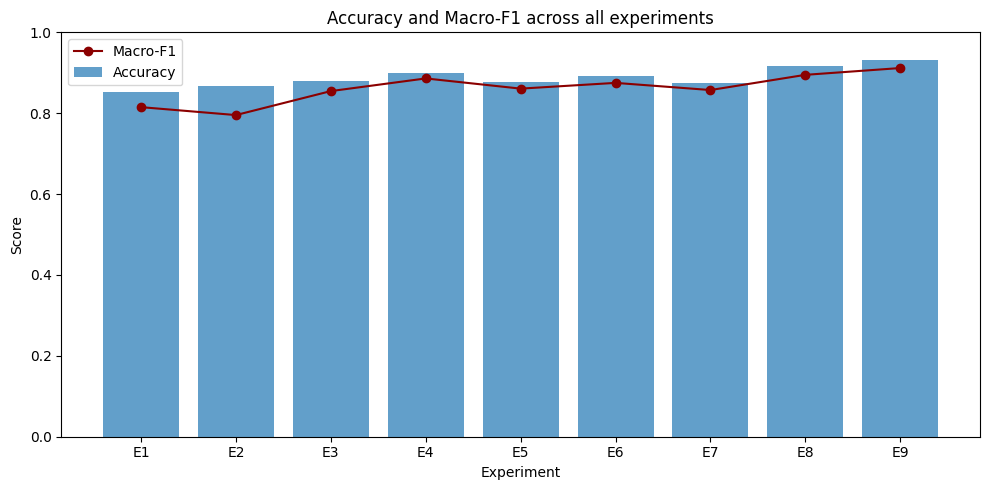

In [23]:
plt.figure(figsize=(10, 5))
order = results_df["Exp"]
plt.bar(order, results_df["Accuracy"], alpha=0.7, label="Accuracy")
plt.plot(order, results_df["Macro-F1"], "o-", color="darkred", label="Macro-F1")
plt.ylim(0, 1); plt.ylabel("Score"); plt.xlabel("Experiment")
plt.title("Accuracy and Macro-F1 across all experiments")
plt.legend(); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/results_overview.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Evaluation and Error Analysis

The results table shows what happened, and this section is where I try to explain why it happened. Learning curves show where overfitting crept in, confusion matrices show exactly which classes ended up mixed up with each other, and the ROC and precision-recall curves show how well each model copes with the class imbalance. Because every model, both classical and deep, was saved into `model_store`, I can pull any of them back out and plot them together side by side.

### 9.1 Learning curves

Learning curves plot the training accuracy and loss against the validation accuracy and loss over the epochs, and a wide gap opening up between the two lines is the classic signature of overfitting. I focus on the from-scratch CNNs and the fine-tuned transfer model here, because those are the experiments where augmentation and the other design choices show up most clearly in the actual shape of the curves.

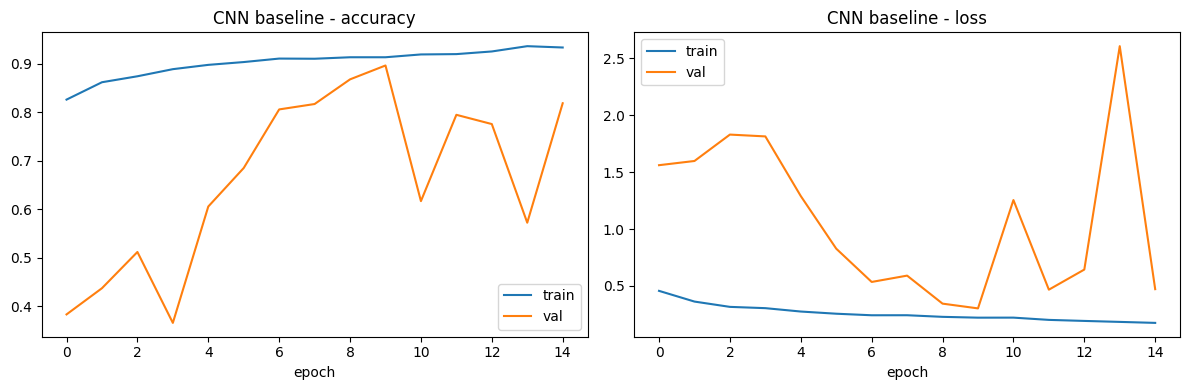

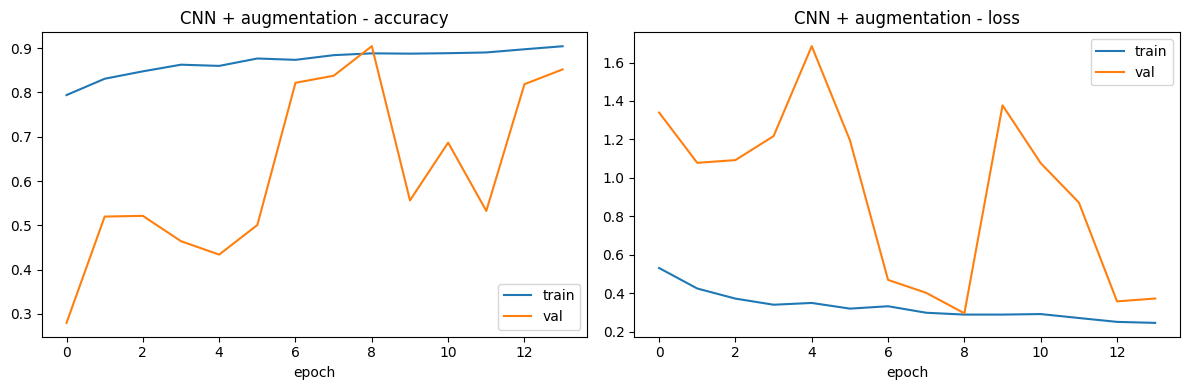

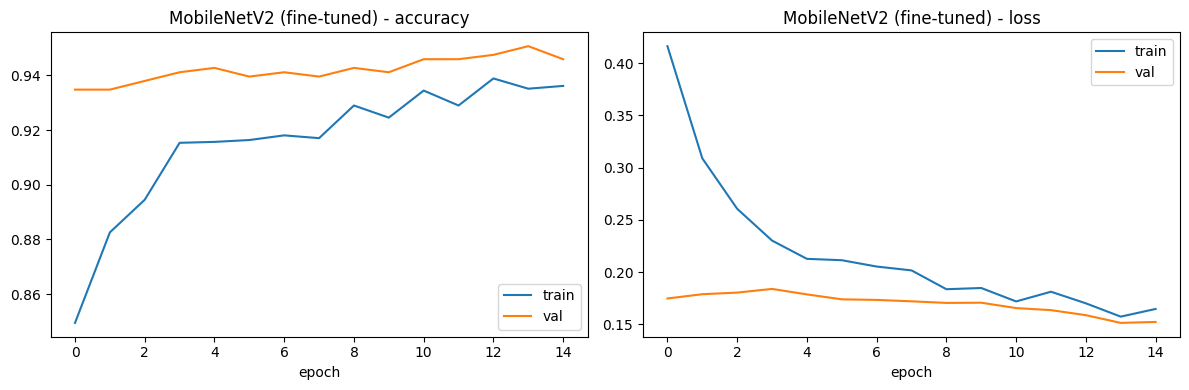

In [24]:
def plot_history(exp_id, fname):
    h = model_store[exp_id]["history"]
    if h is None:
        print(f"{exp_id} has no training history (classical model)."); return
    title = model_store[exp_id]["name"]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
    ax[0].set_title(f"{title} - accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
    ax[1].set_title(f"{title} - loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/{fname}", dpi=120, bbox_inches="tight"); plt.show()

plot_history("E4", "lc_e4.png")
plot_history("E5", "lc_e5.png")
plot_history("E9", "lc_e9.png")

**What the curves showed:** The from-scratch CNN in E4 trained in an unstable way rather than collapsing outright. Its training accuracy climbed smoothly to around 0.93, but the validation accuracy was very jumpy, swinging between roughly 0.57 and 0.90 from epoch to epoch, and the validation loss spiked sharply several times instead of settling down. That pattern points to a model that learns the training data well but does not generalise in a steady way, even though its final test accuracy of 0.898 is actually quite respectable. Turning augmentation on in E5 did not smooth this out the way I had hoped, because the validation curve stayed similarly volatile and the final test accuracy of 0.878 was, if anything, slightly lower than the plain baseline. The fine-tuned MobileNetV2 in E9 looked completely different and far healthier, since its validation accuracy sat above 0.93 from the very first epoch and drifted up towards 0.95 while the validation loss stayed low and flat, which is exactly what you would expect from a model that starts from features already trained on millions of images and only needs to adapt them to maize leaves.

### 9.2 Confusion matrices

The confusion matrix shows exactly which classes are being swapped for which, and my guess before running it was that Common Rust would be easy thanks to its obvious orange spots, while Gray Leaf Spot and Blight would be the hard pair because both of them show similar brownish lesions. To see whether that guess actually held up, I compare the Random Forest model from E2 against the fine-tuned MobileNetV2 from E9, which puts a representative classical model next to the best deep model on the very same test images.

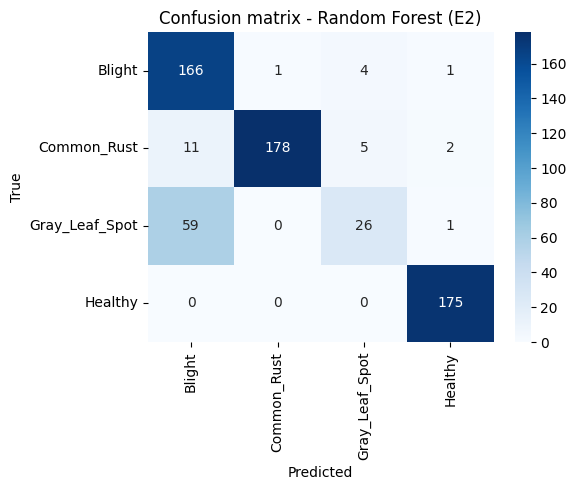

                precision    recall  f1-score   support

        Blight       0.70      0.97      0.81       172
   Common_Rust       0.99      0.91      0.95       196
Gray_Leaf_Spot       0.74      0.30      0.43        86
       Healthy       0.98      1.00      0.99       175

      accuracy                           0.87       629
     macro avg       0.85      0.79      0.80       629
  weighted avg       0.88      0.87      0.85       629



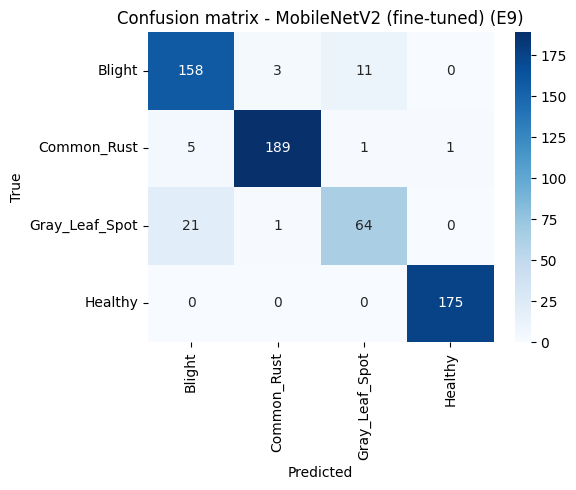

                precision    recall  f1-score   support

        Blight       0.86      0.92      0.89       172
   Common_Rust       0.98      0.96      0.97       196
Gray_Leaf_Spot       0.84      0.74      0.79        86
       Healthy       0.99      1.00      1.00       175

      accuracy                           0.93       629
     macro avg       0.92      0.91      0.91       629
  weighted avg       0.93      0.93      0.93       629



In [25]:
def plot_confusion(exp_id):
    d = model_store[exp_id]
    cm = confusion_matrix(d["y_true"], d["y_pred"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Confusion matrix - {d['name']} ({exp_id})")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/cm_{exp_id}.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(classification_report(d["y_true"], d["y_pred"], target_names=CLASSES))

plot_confusion("E2")
plot_confusion("E9")

Gray Leaf Spot was the hardest class for every model, classical and deep alike, and the most common mistake was exactly the one I had predicted, namely confusing it with Blight because both diseases leave brownish patches on the leaf. The confusion matrices make this very concrete: the Random Forest in E2 recognised only 26 of the 86 Gray Leaf Spot images and sent 59 of them to Blight, which is why its macro-F1 of 0.795 sits so far below its accuracy of 0.867. Even the best model, the fine-tuned MobileNetV2 in E9, still got only about 74% of Gray Leaf Spot right, misreading 21 of the 86 as Blight, while it handled Healthy almost perfectly and Common Rust nearly as well. What I did not expect was that neither imbalance fix helped, because E6 with class weights reached 0.892 accuracy / 0.875 macro-F1 and E7 with oversampling reached 0.874 / 0.857, and neither of them beat the plain baseline CNN in E4 at 0.898 / 0.886. The imbalance is only about 2.28:1, which seems mild enough that the models were already coping with it, so adding class weights or oversampling on top mostly moved the numbers around without fixing the underlying difficulty of the class.

### 9.3 ROC and precision-recall curves

Because the data is imbalanced, the ROC curves on their own can look a bit more optimistic than the model really deserves, whereas precision-recall curves stay far more honest when the class sizes are unequal like they are here. I plot both of them for every class using one-vs-rest predicted probabilities, which makes it very clear whether Gray Leaf Spot is once again turning out to be the weak point.

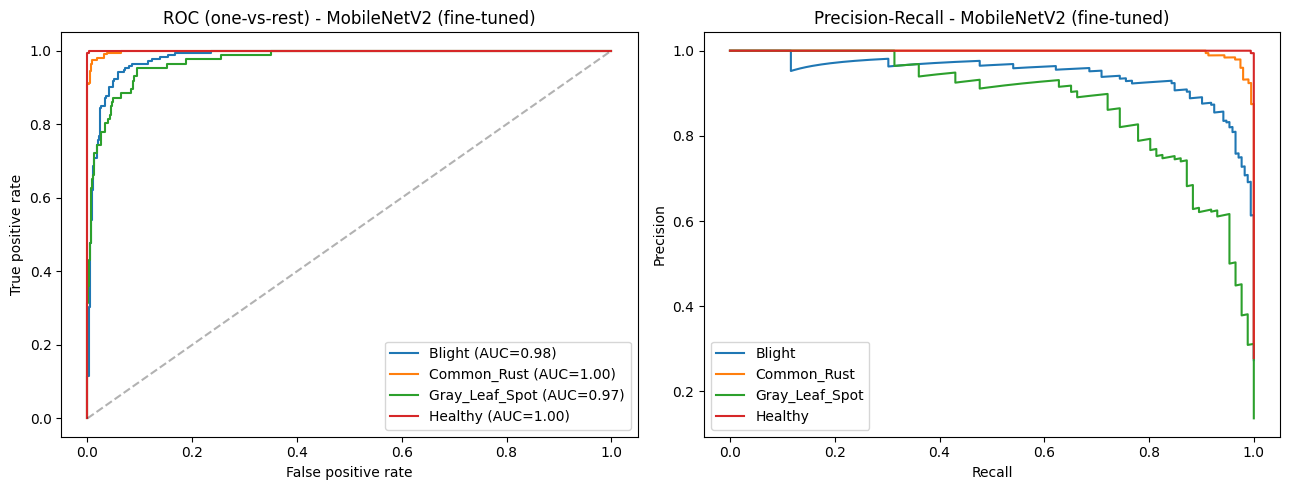

In [26]:
def plot_roc_pr(exp_id):
    d = model_store[exp_id]
    if d["y_prob"] is None:
        print(f"{exp_id} has no probabilities."); return
    y_true = d["y_true"]; y_prob = d["y_prob"]
    y_true_oh = np.eye(NUM_CLASSES)[y_true]
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for i, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_prob[:, i])
        ax[0].plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
        prec, rec, _ = precision_recall_curve(y_true_oh[:, i], y_prob[:, i])
        ax[1].plot(rec, prec, label=cls)
    ax[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax[0].set_title(f"ROC (one-vs-rest) - {d['name']}")
    ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate"); ax[0].legend()
    ax[1].set_title(f"Precision-Recall - {d['name']}")
    ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/roc_pr_{exp_id}.png", dpi=120, bbox_inches="tight")
    plt.show()

plot_roc_pr("E9")

### 9.4 Misclassified images

Looking at the actual images that the best model got wrong often explains the confusion matrix far better than any single number ever could. Some of the mistakes turn out to be blurry photos or awkward camera angles, while others are genuinely early-stage lesions that even a human expert would find very hard to call correctly.

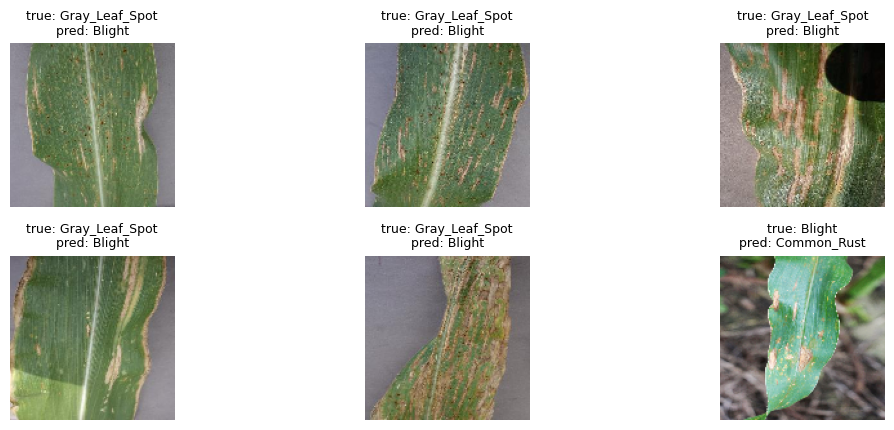

In [27]:
def show_mistakes(exp_id, n=6):
    d = model_store[exp_id]
    wrong = np.where(d["y_true"] != d["y_pred"])[0]
    if len(wrong) == 0:
        print("No misclassifications."); return
    pick = wrong[:n]
    test_paths = test_df.filepath.values
    plt.figure(figsize=(12, 2.2 * ((len(pick) + 2) // 3)))
    for j, idx in enumerate(pick):
        plt.subplot((len(pick) + 2) // 3, 3, j + 1)
        plt.imshow(load_img(test_paths[idx], target_size=(128, 128)))
        plt.title(f"true: {CLASSES[d['y_true'][idx]]}\npred: {CLASSES[d['y_pred'][idx]]}", fontsize=9)
        plt.axis("off")
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/mistakes_{exp_id}.png", dpi=120, bbox_inches="tight")
    plt.show()

show_mistakes("E9")

## 10. Discussion and Conclusion

**ML vs DL:** Among the classical models the tuned SVM was the strongest, reaching 0.881 accuracy and 0.855 macro-F1, comfortably ahead of Logistic Regression at 0.852 / 0.815 and Random Forest at 0.867 / 0.795. What really stands out, though, is that even the plain from-scratch CNN in E4 already beat all three classical models at 0.898 / 0.886, so on this dataset the deep models had the edge before any special tricks were added at all. The handcrafted features clearly carry the classical models a long way, but they appear to hit a ceiling that the convolutional network gets past on its own.

**Effect of augmentation (E4 vs E5):** This is where the results genuinely surprised me, because augmentation did not help. The baseline CNN in E4 reached 0.898 accuracy and 0.886 macro-F1, while the very same architecture with augmentation in E5 actually came out slightly lower at 0.878 / 0.861. Looking at the learning curves, the baseline was not overfitting in the dramatic way I had assumed, so there was not much room for augmentation to improve things, and within the fixed number of training epochs the harder, augmented inputs seem to have cost a little accuracy rather than buying extra generalisation. The honest lesson is that augmentation is not automatically helpful, and on a dataset that is already fairly varied it can be neutral or even mildly harmful.

**Imbalance handling (E4 vs E6 vs E7):** Neither imbalance fix beat the plain baseline either. Class weights in E6 gave 0.892 / 0.875 and oversampling in E7 gave 0.874 / 0.857, both below the E4 baseline of 0.898 / 0.886, although class weights did recover a little ground compared with the augmented E5. My reading is that a 2.28:1 imbalance is simply not severe enough to need an explicit correction here, so reweighting and oversampling mostly added noise instead of solving a real problem. This is a useful corrective to the habit of reaching for imbalance fixes automatically, since the right first step is to check whether the imbalance is actually hurting before treating it.

**Transfer learning (E8 vs E9):** Transfer learning was the clear winner. Freezing the MobileNetV2 backbone in E8 already reached 0.917 / 0.895 with very little training time, and fine-tuning the top layers in E9 pushed this to 0.932 / 0.912, the best result anywhere in the project. Just as important as the score is the stability, because the fine-tuned model trained cleanly, with the validation accuracy tracking the training accuracy and the validation loss staying low and flat, which is a sharp contrast to the jumpy curves of the from-scratch CNNs. Starting from features already learned on millions of images gave a model that was both more accurate and much better behaved during training.

**Error patterns:** Gray Leaf Spot was the weak point all the way through, for every single model, and it kept getting confused with Blight because both diseases look like brownish spots on the leaf. Even the best model only recognised about three quarters of the Gray Leaf Spot images, and the Random Forest recognised barely a third of them, so this is a problem that none of the approaches really solved. Part of the cause is the dataset itself, because Gray Leaf Spot is the smallest class and its images mix clean lab photos from PlantVillage with messier field shots from PlantDoc, so the model is being asked to learn a harder concept from fewer and more varied examples.

**Bias and variance:** The from-scratch CNNs in E4 and E5 behaved like higher-variance models, in the sense that they fit the training data well but produced unstable, spiking validation curves, which means their good final accuracy came with a lot of epoch-to-epoch uncertainty. The pretrained backbone in E8 and E9 reduced that variance a great deal, because it starts from features that already work across many visual tasks, so the model did not have to build everything from scratch on a small dataset and its training stayed smooth and predictable.

**Dataset limitations:** The PlantVillage and PlantDoc images were taken under very different conditions in terms of lighting, background, and leaf angle, and Gray Leaf Spot is the class that is most affected by this mismatch. Because of that, the accuracy numbers reported here are probably a little optimistic compared with what would actually happen on real field photos that the models have never seen before.

**Future work:** The most useful next step would be collecting more Gray Leaf Spot field images, since that would help close both the class imbalance and the distribution gap at the same time, and testing a bigger backbone such as EfficientNetV2 would also be well worth trying. The most honest test of all, though, would be running the best model on a completely separate field dataset that was never part of the training distribution, just to see how well it really holds up once it is out in the real world.

### Conclusion

The best single model was the fine-tuned MobileNetV2 at 0.932 accuracy and 0.912 macro-F1, but the findings that taught me the most were the ones I did not expect. Deep learning had the edge from the start, since even the plain baseline CNN beat every classical model, and yet the tuned SVM stayed respectably competitive on nothing more than handcrafted features. Augmentation did not help on this dataset and slightly hurt, and the two explicit imbalance fixes did not beat the plain baseline either, which together are a reminder that standard tricks only pay off when the problem actually calls for them. Across every model Gray Leaf Spot stayed the weak point, confused again and again with Blight, and properly fixing that would need more and better field data rather than a different algorithm.

## 11. Export E9 for the web app

The web app in `web/` runs this same fine-tuned MobileNetV2 inside the farmer's browser, so the model has to leave Colab in two forms. `maize_e9.keras` is the trained model itself, worth keeping so that nothing here ever has to be retrained. `tfjs_model/` is the same model converted for TensorFlow.js, quantised to float16 so that the download stays around 4 to 5 MB on a phone. I save the Keras copy first, before installing the converter, because installing `tensorflowjs` can shuffle the TensorFlow version in the runtime.

Once both downloads finish, unzip `tfjs_model.zip` and copy its contents into `web/model/`, so that `web/model/model.json` sits beside its `.bin` shards.


In [ ]:
# Run this after Experiment 9, with `transfer` still holding the fine-tuned model.

# 1. The trained model itself, so this never has to be retrained.
transfer.save("maize_e9.keras")

# 2. The same model as a SavedModel, which is what the converter reads.
transfer.export("maize_e9_savedmodel")

!pip install -q tensorflowjs
!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model \n    --quantize_float16="*" maize_e9_savedmodel tfjs_model

!ls -la tfjs_model
!zip -qr tfjs_model.zip tfjs_model

from google.colab import files
files.download("tfjs_model.zip")
files.download("maize_e9.keras")
